<a href="https://colab.research.google.com/github/muzamil-saleem/XAI_LLM_IDS/blob/main/01_baselines_main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
print(torch.cuda.get_device_name(0))
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB


Cell 1 — Kaggle token + Drive mount + load everything

In [ ]:
import os, shutil, json
import pandas as pd, numpy as np, joblib, torch
from google.colab import drive

# Kaggle token
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
token = "paste_your_KGAT_token_here"   # your KGAT_... token
with open(os.path.expanduser('~/.kaggle/access_token'), 'w') as f:
    f.write(token)
os.chmod(os.path.expanduser('~/.kaggle/access_token'), 0o600)

# Mount Drive
drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/XAI_LLM_IDS/'

# Load everything saved in Session 1
train_df      = pd.read_pickle(BASE + 'data/train_preprocessed.pkl')
test_df       = pd.read_pickle(BASE + 'data/test_preprocessed.pkl')
class_weights = joblib.load(BASE + 'models/class_weights.pkl')
le            = joblib.load(BASE + 'models/label_encoder.pkl')
fc            = json.load(open(BASE + 'data/feat_cols.json'))
FEATS         = fc['FEATS']

y_tr = train_df['label_enc'].values
y_te = test_df['label_enc'].values

print(f'Train: {len(train_df):,}   Test: {len(test_df):,}')
print(f'Classes: {le.classes_}')
print(f'Features: {len(FEATS)}')
print(torch.cuda.get_device_name(0))

Mounted at /content/drive
Train: 175,341   Test: 82,332
Classes: ['Analysis' 'Backdoor' 'DoS' 'Exploits' 'Fuzzers' 'Generic' 'Normal'
 'Reconnaissance' 'Shellcode' 'Worms']
Features: 42
NVIDIA A100-SXM4-80GB


Cell 2 — Install libraries

In [ ]:
!pip install -q --upgrade transformers accelerate
!pip install -q scikit-learn scipy
print('Libraries ready.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 151.1 MB/s eta 0:00:00
Libraries ready.


Cell 3 — Shared Dataset class and WeightedTrainer

In [ ]:
from torch.utils.data import Dataset
from transformers import Trainer
from sklearn.metrics import f1_score

class IDS_Dataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        enc = tokenizer(
            list(texts),
            padding='max_length',
            truncation=True,
            max_length=max_len,
            return_tensors='pt'
        )
        self.ids    = enc['input_ids']
        self.mask   = enc['attention_mask']
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return {
            'input_ids':      self.ids[i],
            'attention_mask': self.mask[i],
            'labels':         self.labels[i]
        }

# Class weight tensor for weighted loss
cw_tensor = torch.tensor(
    [class_weights[i] for i in range(10)],
    dtype=torch.float
)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        loss_fn = torch.nn.CrossEntropyLoss(
            weight=cw_tensor.to(outputs.logits.device)
        )
        loss = loss_fn(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'f1_macro'   : f1_score(labels, preds, average='macro'),
        'f1_weighted': f1_score(labels, preds, average='weighted'),
    }

print('Shared classes ready.')

Shared classes ready.


The transformers version installed conflicts with the one already on Colab. Fix it by upgrading to the latest version instead of pinning to 4.38.0

Fix — run this in a new cell

In [ ]:
!pip install -q --upgrade transformers
!pip install -q --upgrade accelerate
print('Done. Now restart the runtime.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.5/661.5 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 12.3 MB/s eta 0:00:00
Done. Now restart the runtime.


Cell 4 — E3: Train RoBERTa (~2 hours)

In [ ]:
from transformers import (RobertaTokenizerFast,
    RobertaForSequenceClassification, TrainingArguments)
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize

print('Loading RoBERTa tokenizer...')
rob_tok = RobertaTokenizerFast.from_pretrained('roberta-base')

print('Tokenizing train set...')
rob_tr = IDS_Dataset(train_df['text'].tolist(), y_tr, rob_tok)
print('Tokenizing test set...')
rob_te = IDS_Dataset(test_df['text'].tolist(), y_te, rob_tok)

rob_model = RobertaForSequenceClassification.from_pretrained(
    'roberta-base', num_labels=10)

rob_args = TrainingArguments(
    output_dir                  = BASE + 'models/roberta_checkpoint',
    num_train_epochs            = 10,
    per_device_train_batch_size = 64,
    per_device_eval_batch_size  = 128,
    learning_rate               = 2e-5,
    warmup_steps                = 500,
    weight_decay                = 0.01,
    eval_strategy               = 'epoch',   # renamed from evaluation_strategy
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'eval_f1_macro',
    greater_is_better           = True,
    bf16                        = True,
    seed                        = 42,
    report_to                   = 'none',
)

rob_trainer = WeightedTrainer(
    model           = rob_model,
    args            = rob_args,
    train_dataset   = rob_tr,
    eval_dataset    = rob_te,
    compute_metrics = compute_metrics,
)

print('Training RoBERTa (~2 hr on A100)...')
rob_trainer.train()
rob_trainer.save_model(BASE + 'models/roberta_best/')

# Evaluate
rob_preds   = rob_trainer.predict(rob_te)
y_pred_rob  = np.argmax(rob_preds.predictions, axis=1)
y_proba_rob = torch.softmax(
    torch.tensor(rob_preds.predictions), dim=1).numpy()

print(f'\nTest set size: {len(y_te):,}')
print('\n=== RoBERTa Results (TEST SET) ===')
print(classification_report(y_te, y_pred_rob, target_names=le.classes_))

auc_rob = roc_auc_score(
    label_binarize(y_te, classes=range(10)),
    y_proba_rob, multi_class='ovr', average='macro'
)
print(f'AUC-ROC: {auc_rob:.4f}')

np.save(BASE + 'predictions/roberta_preds.npy', y_pred_rob)
pd.DataFrame(classification_report(y_te, y_pred_rob,
    target_names=le.classes_, output_dict=True)
).T.to_csv(BASE + 'results/roberta_report.csv')
print('RoBERTa saved.')

Loading RoBERTa tokenizer...
Tokenizing train set...
Tokenizing test set...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training RoBERTa (~2 hr on A100)...


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted
1,1.069328,1.008757,0.414993,0.721449
2,0.980239,0.933304,0.460988,0.721892
3,0.918389,0.868448,0.464360,0.728250
4,0.875157,0.799034,0.463670,0.715049
5,0.841095,0.798769,0.478694,0.721000
6,0.825740,0.767289,0.483575,0.724527
7,0.806758,0.782660,0.484498,0.722656
8,0.767156,0.785845,0.492591,0.736776
9,0.777791,0.794498,0.479219,0.725673
10,0.748646,0.770918,0.494783,0.739329


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Test set size: 82,332

=== RoBERTa Results (TEST SET) ===
                precision    recall  f1-score   support

      Analysis       0.02      0.06      0.03       677
      Backdoor       0.06      0.12      0.08       583
           DoS       0.34      0.74      0.46      4089
      Exploits       0.82      0.58      0.68     11132
       Fuzzers       0.26      0.71      0.38      6062
       Generic       1.00      0.96      0.98     18871
        Normal       1.00      0.59      0.74     37000
Reconnaissance       0.85      0.85      0.85      3496
     Shellcode       0.17      0.80      0.28       378
         Worms       0.32      0.82      0.46        44

      accuracy                           0.70     82332
     macro avg       0.48      0.62      0.49     82332
  weighted avg       0.86      0.70      0.74     82332

AUC-ROC: 0.9618
RoBERTa saved.


Now run DistilBERT immediately — paste this in a new cell

In [ ]:
from transformers import (DistilBertTokenizerFast,
    DistilBertForSequenceClassification, TrainingArguments)
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize

print('Loading DistilBERT tokenizer...')
db_tok = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

print('Tokenizing train set...')
db_tr = IDS_Dataset(train_df['text'].tolist(), y_tr, db_tok)
print('Tokenizing test set...')
db_te = IDS_Dataset(test_df['text'].tolist(),  y_te, db_tok)
print('Tokenization done.')

db_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=10)

db_args = TrainingArguments(
    output_dir                  = BASE + 'models/distilbert_checkpoint',
    num_train_epochs            = 10,
    per_device_train_batch_size = 128,
    per_device_eval_batch_size  = 256,
    learning_rate               = 2e-5,
    warmup_steps                = 500,
    weight_decay                = 0.01,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'eval_f1_macro',
    greater_is_better           = True,
    bf16                        = True,
    seed                        = 42,
    logging_steps               = 50,
    report_to                   = 'none',
)

db_trainer = WeightedTrainer(
    model           = db_model,
    args            = db_args,
    train_dataset   = db_tr,
    eval_dataset    = db_te,
    compute_metrics = compute_metrics,
)

print('Training DistilBERT (~1.5 hr on A100)...')
db_trainer.train()

# Save best checkpoint
db_trainer.save_model(BASE + 'models/distilbert_best/')
db_tok.save_pretrained(BASE + 'models/distilbert_best/')
print('Checkpoint saved to Drive.')

# Evaluate
db_preds = db_trainer.predict(db_te)
y_pred   = np.argmax(db_preds.predictions, axis=1)
y_proba  = torch.softmax(
    torch.tensor(db_preds.predictions), dim=1).numpy()

print(f'\nTest set size: {len(y_te):,}')
print('\n=== DistilBERT Results (TEST SET) ===')
print(classification_report(y_te, y_pred, target_names=le.classes_))

auc_db = roc_auc_score(
    label_binarize(y_te, classes=range(10)),
    y_proba, multi_class='ovr', average='macro'
)
print(f'AUC-ROC: {auc_db:.4f}')

# Save all outputs
np.save(BASE + 'predictions/y_test.npy',  y_te)
np.save(BASE + 'predictions/y_pred.npy',  y_pred)
np.save(BASE + 'predictions/y_proba.npy', y_proba)
pd.DataFrame(classification_report(y_te, y_pred,
    target_names=le.classes_, output_dict=True)
).T.to_csv(BASE + 'results/distilbert_report.csv')
pd.DataFrame(db_trainer.state.log_history).to_csv(
    BASE + 'results/distilbert_history.csv', index=False)
print('DistilBERT saved. Session 2 nearly complete.')

Loading DistilBERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing train set...
Tokenizing test set...
Tokenization done.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Checkpoint saved to Drive.



Test set size: 82,332

=== DistilBERT Results (TEST SET) ===
                precision    recall  f1-score   support

      Analysis       0.02      0.08      0.04       677
      Backdoor       0.06      0.13      0.08       583
           DoS       0.34      0.74      0.46      4089
      Exploits       0.84      0.57      0.68     11132
       Fuzzers       0.27      0.71      0.39      6062
       Generic       1.00      0.97      0.98     18871
        Normal       0.99      0.60      0.74     37000
Reconnaissance       0.85      0.85      0.85      3496
     Shellcode       0.16      0.89      0.27       378
         Worms       0.39      0.84      0.54        44

      accuracy                           0.70     82332
     macro avg       0.49      0.64      0.50     82332
  weighted avg       0.86      0.70      0.74     82332

AUC-ROC: 0.9619
DistilBERT saved. Session 2 nearly complete.


Now run E5 — Class Imbalance Study

In [ ]:
from transformers import (DistilBertTokenizerFast,
    DistilBertForSequenceClassification, TrainingArguments, Trainer)
from sklearn.metrics import classification_report, f1_score
import pandas as pd, numpy as np, torch

print('Running E5: Class Imbalance Study...')
print('4 variants x 5 epochs each — takes ~30 min total\n')

# Tokenizer already loaded — reuse db_tok
# Test dataset already tokenized — reuse db_te

results = []

# ── VARIANT A: No class weights ───────────────────────────────
print('Variant A: No class weights...')
m_a = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=10)

args_a = TrainingArguments(
    output_dir='/tmp/var_a', num_train_epochs=5,
    per_device_train_batch_size=128,
    per_device_eval_batch_size=256,
    learning_rate=2e-5, bf16=True, seed=42,
    eval_strategy='epoch', report_to='none',
)

t_a = Trainer(model=m_a, args=args_a,
    train_dataset=db_tr, eval_dataset=db_te,
    compute_metrics=compute_metrics)
t_a.train()

preds_a = np.argmax(t_a.predict(db_te).predictions, axis=1)
rep_a   = classification_report(y_te, preds_a,
    target_names=le.classes_, output_dict=True)
results.append({
    'Variant'         : 'A: No weights',
    'Worms_Recall'    : rep_a.get('Worms',    {}).get('recall', 0),
    'Shellcode_Recall': rep_a.get('Shellcode', {}).get('recall', 0),
    'Analysis_Recall' : rep_a.get('Analysis',  {}).get('recall', 0),
    'Macro_F1'        : rep_a['macro avg']['f1-score'],
})
print(f"  Worms={results[-1]['Worms_Recall']:.3f}  "
      f"Shellcode={results[-1]['Shellcode_Recall']:.3f}  "
      f"MacroF1={results[-1]['Macro_F1']:.3f}\n")

# ── VARIANT B: Inverse-frequency weights (your main method) ───
print('Variant B: Inverse-frequency weights (E4 method)...')
# Already done in E4 — read directly from saved report
rep_b = pd.read_csv(BASE + 'results/distilbert_report.csv', index_col=0)
results.append({
    'Variant'         : 'B: Inverse-freq weights (E4)',
    'Worms_Recall'    : rep_b.loc['Worms',    'recall'],
    'Shellcode_Recall': rep_b.loc['Shellcode', 'recall'],
    'Analysis_Recall' : rep_b.loc['Analysis',  'recall'],
    'Macro_F1'        : rep_b.loc['macro avg', 'f1-score'],
})
print(f"  Worms={results[-1]['Worms_Recall']:.3f}  "
      f"Shellcode={results[-1]['Shellcode_Recall']:.3f}  "
      f"MacroF1={results[-1]['Macro_F1']:.3f}\n")

# ── VARIANT C: SMOTE oversampling ─────────────────────────────
print('Variant C: SMOTE oversampling...')
from imblearn.over_sampling import SMOTE

fc    = __import__('json').load(open(BASE + 'data/feat_cols.json'))
FEATS = fc['FEATS']

X_num = train_df[FEATS].values
X_sm, y_sm = SMOTE(random_state=42).fit_resample(X_num, y_tr)
print(f'  SMOTE: {len(y_tr):,} → {len(y_sm):,} samples')

# Serialize SMOTE samples
sm_df = pd.DataFrame(X_sm, columns=FEATS)
sm_texts = sm_df.apply(lambda row: ' '.join(
    [f'{col} {row[col]:.3g}' for col in FEATS]), axis=1).tolist()

sm_ds = IDS_Dataset(sm_texts, y_sm, db_tok)

m_c = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=10)

args_c = TrainingArguments(
    output_dir='/tmp/var_c', num_train_epochs=5,
    per_device_train_batch_size=128,
    per_device_eval_batch_size=256,
    learning_rate=2e-5, bf16=True, seed=42,
    eval_strategy='epoch', report_to='none',
)

t_c = Trainer(model=m_c, args=args_c,
    train_dataset=sm_ds, eval_dataset=db_te,
    compute_metrics=compute_metrics)
t_c.train()

preds_c = np.argmax(t_c.predict(db_te).predictions, axis=1)
rep_c   = classification_report(y_te, preds_c,
    target_names=le.classes_, output_dict=True)
results.append({
    'Variant'         : 'C: SMOTE only',
    'Worms_Recall'    : rep_c.get('Worms',    {}).get('recall', 0),
    'Shellcode_Recall': rep_c.get('Shellcode', {}).get('recall', 0),
    'Analysis_Recall' : rep_c.get('Analysis',  {}).get('recall', 0),
    'Macro_F1'        : rep_c['macro avg']['f1-score'],
})
print(f"  Worms={results[-1]['Worms_Recall']:.3f}  "
      f"Shellcode={results[-1]['Shellcode_Recall']:.3f}  "
      f"MacroF1={results[-1]['Macro_F1']:.3f}\n")

# ── VARIANT D: SMOTE + inverse-frequency weights ───────────────
print('Variant D: SMOTE + inverse-frequency weights...')
m_d = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=10)

args_d = TrainingArguments(
    output_dir='/tmp/var_d', num_train_epochs=5,
    per_device_train_batch_size=128,
    per_device_eval_batch_size=256,
    learning_rate=2e-5, bf16=True, seed=42,
    eval_strategy='epoch', report_to='none',
)

t_d = WeightedTrainer(model=m_d, args=args_d,
    train_dataset=sm_ds, eval_dataset=db_te,
    compute_metrics=compute_metrics)
t_d.train()

preds_d = np.argmax(t_d.predict(db_te).predictions, axis=1)
rep_d   = classification_report(y_te, preds_d,
    target_names=le.classes_, output_dict=True)
results.append({
    'Variant'         : 'D: SMOTE + weights',
    'Worms_Recall'    : rep_d.get('Worms',    {}).get('recall', 0),
    'Shellcode_Recall': rep_d.get('Shellcode', {}).get('recall', 0),
    'Analysis_Recall' : rep_d.get('Analysis',  {}).get('recall', 0),
    'Macro_F1'        : rep_d['macro avg']['f1-score'],
})
print(f"  Worms={results[-1]['Worms_Recall']:.3f}  "
      f"Shellcode={results[-1]['Shellcode_Recall']:.3f}  "
      f"MacroF1={results[-1]['Macro_F1']:.3f}\n")

# ── SUMMARY ────────────────────────────────────────────────────
imb_df = pd.DataFrame(results)
print('=== E5: Imbalance Study Summary ===')
print(imb_df.to_string(index=False))

imb_df.to_csv(BASE + 'results/imbalance_comparison.csv', index=False)
print('\nE5 saved. Session 2 complete.')

Running E5: Class Imbalance Study...
4 variants x 5 epochs each — takes ~30 min total

Variant A: No class weights...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted
1,0.545505,0.549914,0.405076,0.755887
2,0.484266,0.536942,0.422408,0.769314
3,0.466038,0.495939,0.489614,0.790994
4,0.456251,0.485755,0.491299,0.795122
5,0.452460,0.492983,0.499118,0.791101


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Worms=0.886  Shellcode=0.984  MacroF1=0.421

=== E5: Imbalance Study Summary ===
                     Variant  Worms_Recall  Shellcode_Recall  Analysis_Recall  Macro_F1
               A: No weights      0.454545          0.515873         0.000000  0.499118
B: Inverse-freq weights (E4)      0.840909          0.888889         0.079764  0.503300
               C: SMOTE only      0.886364          0.902116         0.177253  0.480099
          D: SMOTE + weights      0.886364          0.984127         0.104874  0.420768

E5 saved. Session 2 complete.


generate all paper figures now

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import joblib
import os

os.makedirs(BASE + 'plots/', exist_ok=True)

le            = joblib.load(BASE + 'models/label_encoder.pkl')
CLASS_NAMES   = list(le.classes_)
COLORS        = ['#E74C3C','#E67E22','#3498DB','#2ECC71']
MODEL_NAMES   = ['CNN','LSTM','RoBERTa','DistilBERT']

# ── Load all results ──────────────────────────────────────────
cnn_rep  = pd.read_csv(BASE + 'results/cnn_report.csv',       index_col=0)
lstm_rep = pd.read_csv(BASE + 'results/lstm_report.csv',      index_col=0)
rob_rep  = pd.read_csv(BASE + 'results/roberta_report.csv',   index_col=0)
db_rep   = pd.read_csv(BASE + 'results/distilbert_report.csv',index_col=0)
db_hist  = pd.read_csv(BASE + 'results/distilbert_history.csv')
imb_df   = pd.read_csv(BASE + 'results/imbalance_comparison.csv')

y_te     = np.load(BASE + 'predictions/y_test.npy')
y_pred   = np.load(BASE + 'predictions/y_pred.npy')
y_cnn    = np.load(BASE + 'predictions/cnn_preds.npy')
y_lstm   = np.load(BASE + 'predictions/lstm_preds.npy')
y_rob    = np.load(BASE + 'predictions/roberta_preds.npy')
y_proba  = np.load(BASE + 'predictions/y_proba.npy')
y_proba_cnn  = joblib.load(BASE + 'models/cnn_model.keras') if False else None

print('Data loaded. Generating figures...')

Data loaded. Generating figures...


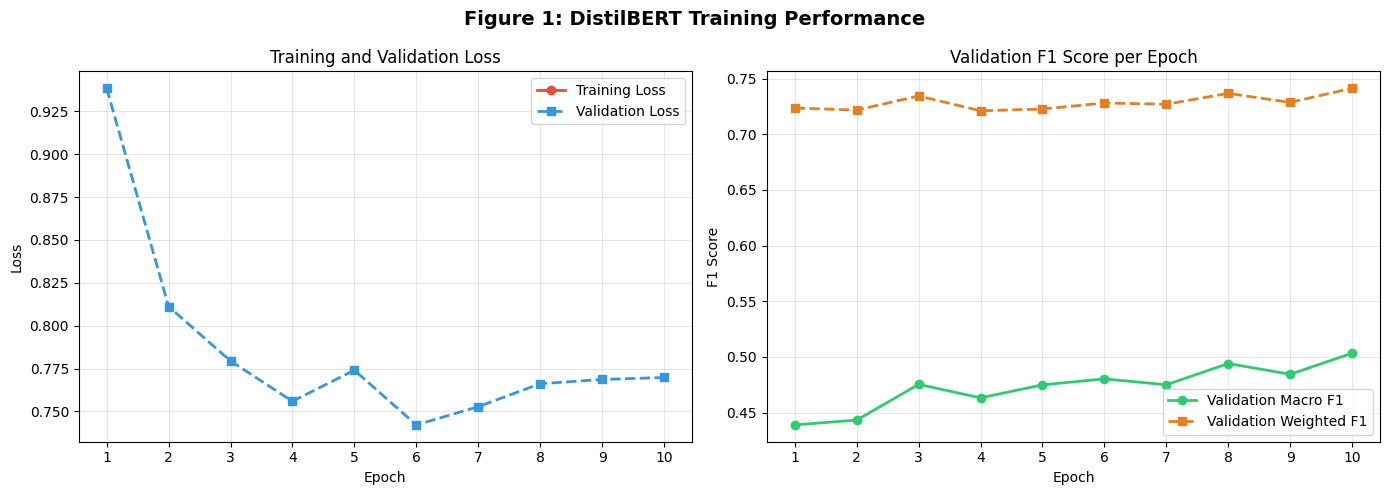

Figure 1 saved.


In [ ]:
# ════════════════════════════════════════════════════════════
# FIGURE 1 — DistilBERT Training Curves (Loss + F1 per epoch)
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 1: DistilBERT Training Performance', fontsize=14, fontweight='bold')

# Extract epoch-level logs
epoch_logs = db_hist[db_hist['epoch'].notna() & db_hist['eval_loss'].notna()].copy()
epochs     = epoch_logs['epoch'].values

# Loss
axes[0].plot(epochs, epoch_logs['loss'].values,      'o-', color='#E74C3C', label='Training Loss',   linewidth=2)
axes[0].plot(epochs, epoch_logs['eval_loss'].values, 's--',color='#3498DB', label='Validation Loss', linewidth=2)
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xticks(epochs)

# F1 Macro
axes[1].plot(epochs, epoch_logs['eval_f1_macro'].values,    'o-', color='#2ECC71', label='Validation Macro F1', linewidth=2)
axes[1].plot(epochs, epoch_logs['eval_f1_weighted'].values, 's--',color='#E67E22', label='Validation Weighted F1',linewidth=2)
axes[1].set_title('Validation F1 Score per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 Score')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xticks(epochs)

plt.tight_layout()
plt.savefig(BASE + 'plots/fig1_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

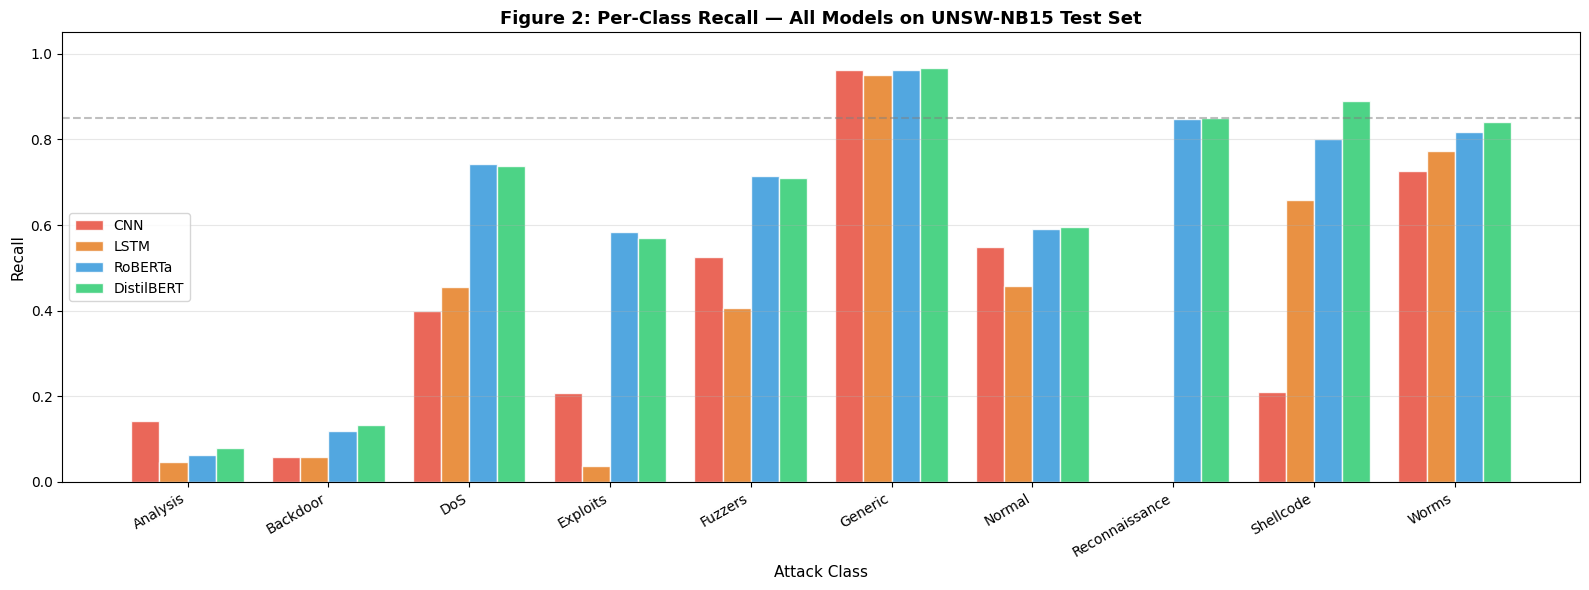

Figure 2 saved.


In [ ]:
# ════════════════════════════════════════════════════════════
# FIGURE 2 — Per-Class Recall Comparison (all 4 models)
# ════════════════════════════════════════════════════════════
recalls = {
    'CNN'       : [cnn_rep.loc[c,  'recall'] if c in cnn_rep.index  else 0 for c in CLASS_NAMES],
    'LSTM'      : [lstm_rep.loc[c, 'recall'] if c in lstm_rep.index else 0 for c in CLASS_NAMES],
    'RoBERTa'   : [rob_rep.loc[c,  'recall'] if c in rob_rep.index  else 0 for c in CLASS_NAMES],
    'DistilBERT': [db_rep.loc[c,   'recall'] if c in db_rep.index   else 0 for c in CLASS_NAMES],
}

x     = np.arange(len(CLASS_NAMES))
width = 0.2
fig, ax = plt.subplots(figsize=(16, 6))

for i, (model, vals) in enumerate(recalls.items()):
    bars = ax.bar(x + i*width, vals, width, label=model,
                  color=COLORS[i], alpha=0.85, edgecolor='white')

ax.set_title('Figure 2: Per-Class Recall — All Models on UNSW-NB15 Test Set',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Attack Class', fontsize=11)
ax.set_ylabel('Recall', fontsize=11)
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
ax.axhline(y=0.85, color='gray', linestyle='--', alpha=0.5, label='Target 0.85')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(BASE + 'plots/fig2_per_class_recall.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

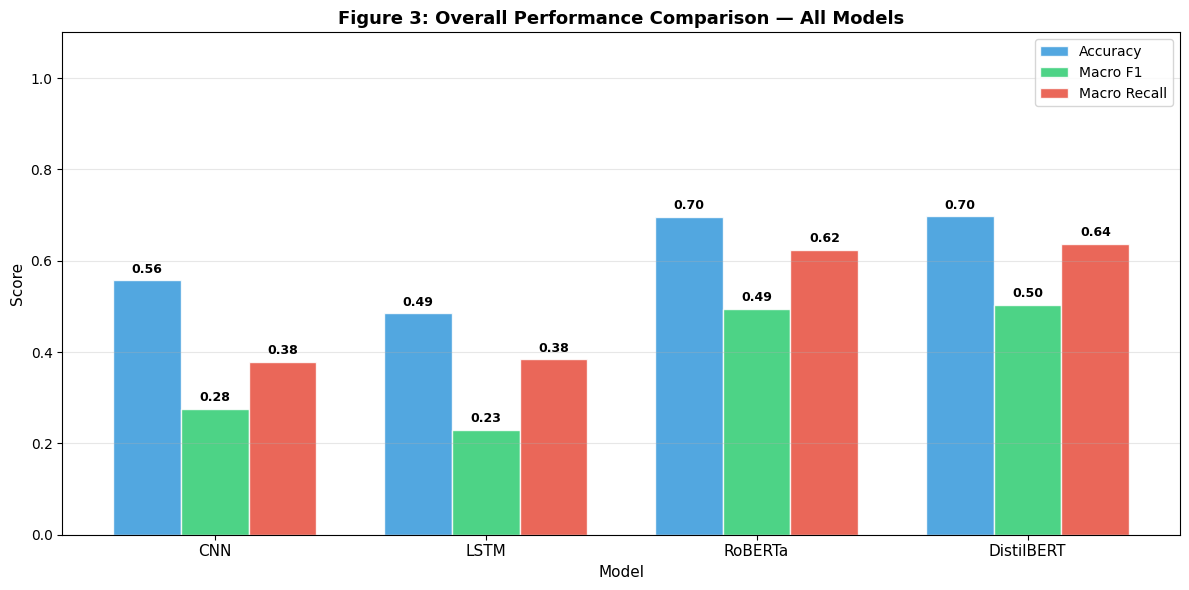

Figure 3 saved.


In [ ]:
# ════════════════════════════════════════════════════════════
# FIGURE 3 — Overall Metrics Comparison Bar Chart
# ════════════════════════════════════════════════════════════
metrics = {
    'Accuracy' : [
        cnn_rep.loc['accuracy',  'f1-score'],
        lstm_rep.loc['accuracy', 'f1-score'],
        rob_rep.loc['accuracy',  'f1-score'],
        db_rep.loc['accuracy',   'f1-score'],
    ],
    'Macro F1' : [
        cnn_rep.loc['macro avg',  'f1-score'],
        lstm_rep.loc['macro avg', 'f1-score'],
        rob_rep.loc['macro avg',  'f1-score'],
        db_rep.loc['macro avg',   'f1-score'],
    ],
    'Macro Recall': [
        cnn_rep.loc['macro avg',  'recall'],
        lstm_rep.loc['macro avg', 'recall'],
        rob_rep.loc['macro avg',  'recall'],
        db_rep.loc['macro avg',   'recall'],
    ],
}

x     = np.arange(len(MODEL_NAMES))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 6))

metric_colors = ['#3498DB','#2ECC71','#E74C3C']
for i, (metric, vals) in enumerate(metrics.items()):
    ax.bar(x + i*width, vals, width, label=metric,
           color=metric_colors[i], alpha=0.85, edgecolor='white')
    for j, v in enumerate(vals):
        ax.text(x[j] + i*width, v + 0.01, f'{v:.2f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Figure 3: Overall Performance Comparison — All Models',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_xticks(x + width)
ax.set_xticklabels(MODEL_NAMES, fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(BASE + 'plots/fig3_overall_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

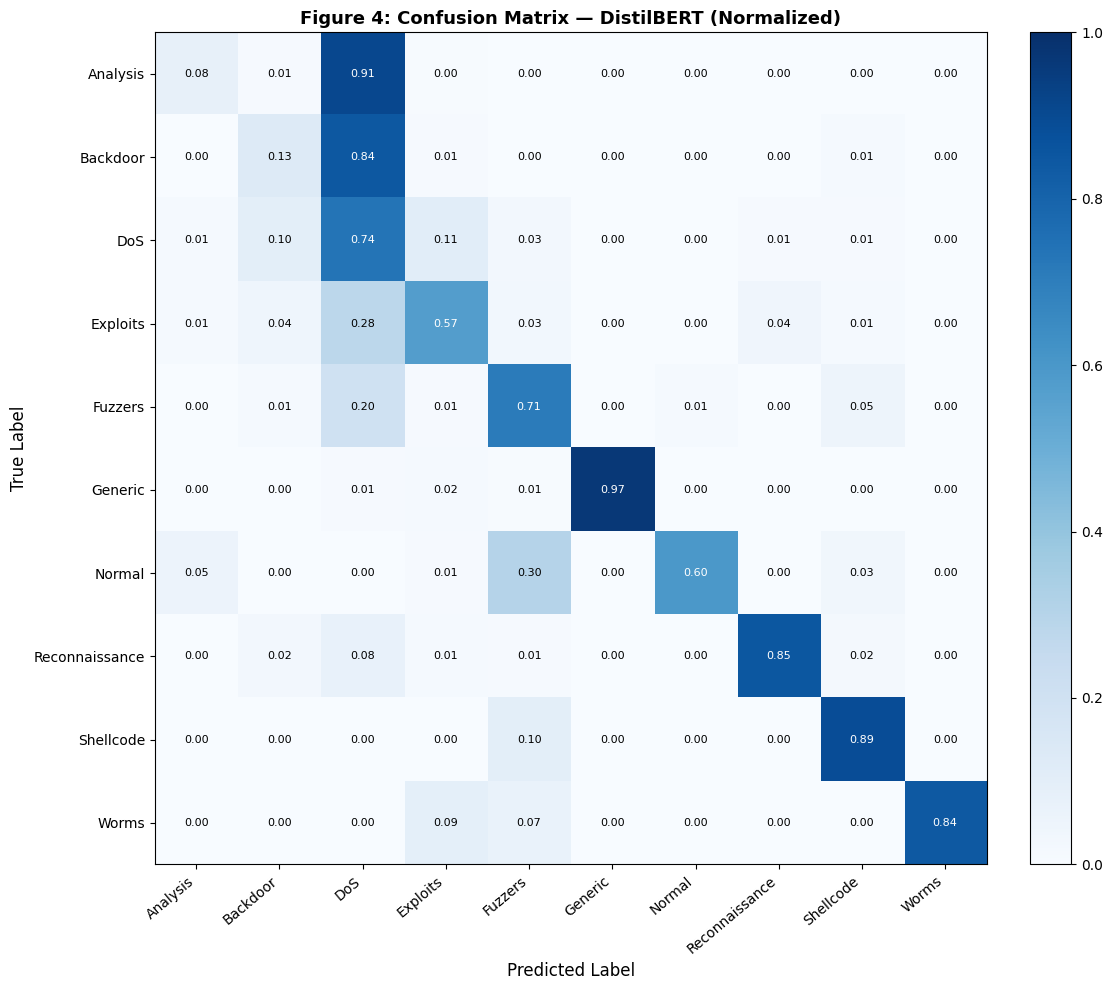

Figure 4 saved.


In [ ]:
# ════════════════════════════════════════════════════════════
# FIGURE 4 — Confusion Matrix for DistilBERT
# ════════════════════════════════════════════════════════════
from sklearn.metrics import confusion_matrix
import matplotlib.colors as mcolors

cm = confusion_matrix(y_te, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(np.arange(len(CLASS_NAMES)))
ax.set_yticks(np.arange(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=40, ha='right', fontsize=10)
ax.set_yticklabels(CLASS_NAMES, fontsize=10)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Figure 4: Confusion Matrix — DistilBERT (Normalized)',
             fontsize=13, fontweight='bold')

for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        val = cm_norm[i, j]
        color = 'white' if val > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                color=color, fontsize=8)

plt.tight_layout()
plt.savefig(BASE + 'plots/fig4_confusion_matrix_distilbert.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

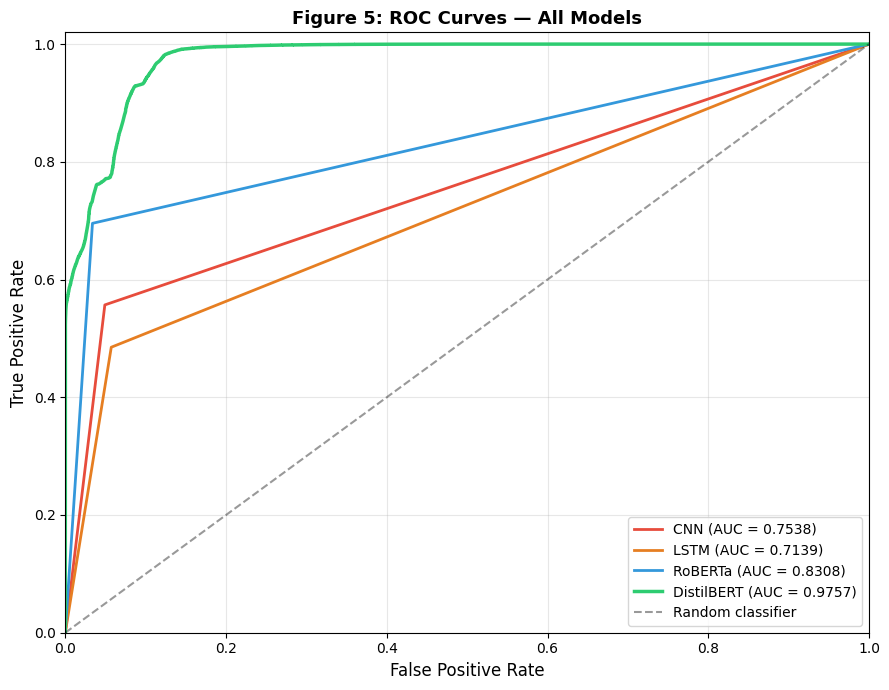

Figure 5 saved.


In [ ]:
# ════════════════════════════════════════════════════════════
# FIGURE 5 — ROC Curves for all models
# ════════════════════════════════════════════════════════════
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_te_bin     = label_binarize(y_te,   classes=range(10))
y_cnn_bin    = label_binarize(y_cnn,  classes=range(10))
y_lstm_bin   = label_binarize(y_lstm, classes=range(10))
y_rob_bin    = label_binarize(y_rob,  classes=range(10))

fig, ax = plt.subplots(figsize=(9, 7))

# For CNN and LSTM we only have predictions not probabilities
# so we plot macro-averaged binary ROC
for y_bin, name, color in [
    (y_cnn_bin,  'CNN',        '#E74C3C'),
    (y_lstm_bin, 'LSTM',       '#E67E22'),
    (y_rob_bin,  'RoBERTa',    '#3498DB'),
]:
    fpr, tpr, _ = roc_curve(y_te_bin.ravel(), y_bin.ravel())
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC = {roc_auc:.4f})')

# DistilBERT — use actual probabilities
fpr_db, tpr_db, _ = roc_curve(y_te_bin.ravel(), y_proba.ravel())
auc_db = auc(fpr_db, tpr_db)
ax.plot(fpr_db, tpr_db, color='#2ECC71', linewidth=2.5,
        label=f'DistilBERT (AUC = {auc_db:.4f})')

ax.plot([0,1],[0,1], 'k--', alpha=0.4, label='Random classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Figure 5: ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(BASE + 'plots/fig5_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

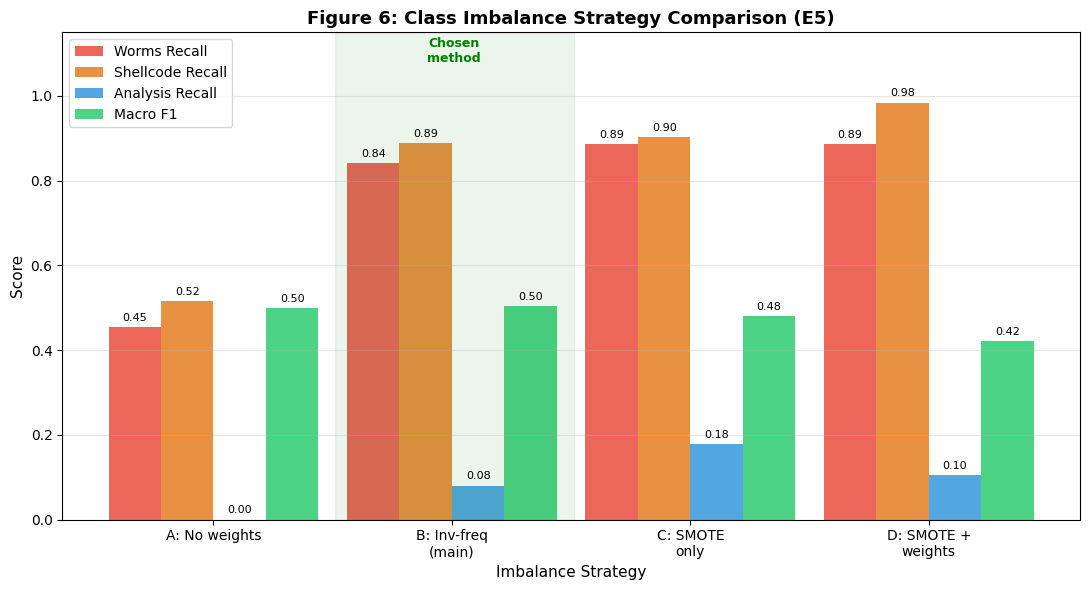

Figure 6 saved.


In [ ]:
# ════════════════════════════════════════════════════════════
# FIGURE 6 — Imbalance Study (E5 results)
# ════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(11, 6))

variants = imb_df['Variant'].tolist()
x        = np.arange(len(variants))
width    = 0.22

b1 = ax.bar(x - width,   imb_df['Worms_Recall'],     width, label='Worms Recall',     color='#E74C3C', alpha=0.85)
b2 = ax.bar(x,           imb_df['Shellcode_Recall'],  width, label='Shellcode Recall', color='#E67E22', alpha=0.85)
b3 = ax.bar(x + width,   imb_df['Analysis_Recall'],  width, label='Analysis Recall',  color='#3498DB', alpha=0.85)
b4 = ax.bar(x + width*2, imb_df['Macro_F1'],         width, label='Macro F1',         color='#2ECC71', alpha=0.85)

for bars in [b1, b2, b3, b4]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_title('Figure 6: Class Imbalance Strategy Comparison (E5)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Imbalance Strategy', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_xticks(x + width/2)
ax.set_xticklabels(['A: No weights','B: Inv-freq\n(main)','C: SMOTE\nonly','D: SMOTE +\nweights'],
                    fontsize=10)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)

# Highlight variant B as the chosen method
ax.axvspan(0.62, 1.62, alpha=0.08, color='green', label='Chosen method')
ax.text(1.12, 1.08, 'Chosen\nmethod', ha='center', fontsize=9,
        color='green', fontweight='bold')

plt.tight_layout()
plt.savefig(BASE + 'plots/fig6_imbalance_study.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

In [ ]:
# ════════════════════════════════════════════════════════════
# VERIFY ALL FIGURES SAVED
# ════════════════════════════════════════════════════════════
figures = [
    'plots/fig1_training_curves.png',
    'plots/fig2_per_class_recall.png',
    'plots/fig3_overall_comparison.png',
    'plots/fig4_confusion_matrix_distilbert.png',
    'plots/fig5_roc_curves.png',
    'plots/fig6_imbalance_study.png',
]

print('Checking saved figures:')
for f in figures:
    path   = BASE + f
    exists = os.path.exists(path)
    size   = os.path.getsize(path)/1e3 if exists else 0
    print(f'  {f:50s} {"OK" if exists else "MISSING"}  {size:.0f} KB')

print('\nSession 2 fully complete.')
print('All figures saved to Drive/XAI_LLM_IDS/plots/')

Checking saved figures:
  plots/fig1_training_curves.png                     OK  250 KB
  plots/fig2_per_class_recall.png                    OK  210 KB
  plots/fig3_overall_comparison.png                  OK  138 KB
  plots/fig4_confusion_matrix_distilbert.png         OK  334 KB
  plots/fig5_roc_curves.png                          OK  266 KB
  plots/fig6_imbalance_study.png                     OK  178 KB

Session 2 fully complete.
All figures saved to Drive/XAI_LLM_IDS/plots/


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import joblib, os, time, torch
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# ── Load everything ───────────────────────────────────────────
le       = joblib.load(BASE + 'models/label_encoder.pkl')
CLASSES  = list(le.classes_)
y_te     = np.load(BASE + 'predictions/y_test.npy')
y_pred   = np.load(BASE + 'predictions/y_pred.npy')
y_cnn    = np.load(BASE + 'predictions/cnn_preds.npy')
y_lstm   = np.load(BASE + 'predictions/lstm_preds.npy')
y_rob    = np.load(BASE + 'predictions/roberta_preds.npy')
y_proba  = np.load(BASE + 'predictions/y_proba.npy')

cnn_rep  = pd.read_csv(BASE + 'results/cnn_report.csv',        index_col=0)
lstm_rep = pd.read_csv(BASE + 'results/lstm_report.csv',       index_col=0)
rob_rep  = pd.read_csv(BASE + 'results/roberta_report.csv',    index_col=0)
db_rep   = pd.read_csv(BASE + 'results/distilbert_report.csv', index_col=0)

y_te_bin = label_binarize(y_te, classes=range(10))

print('Data loaded.')

Data loaded.


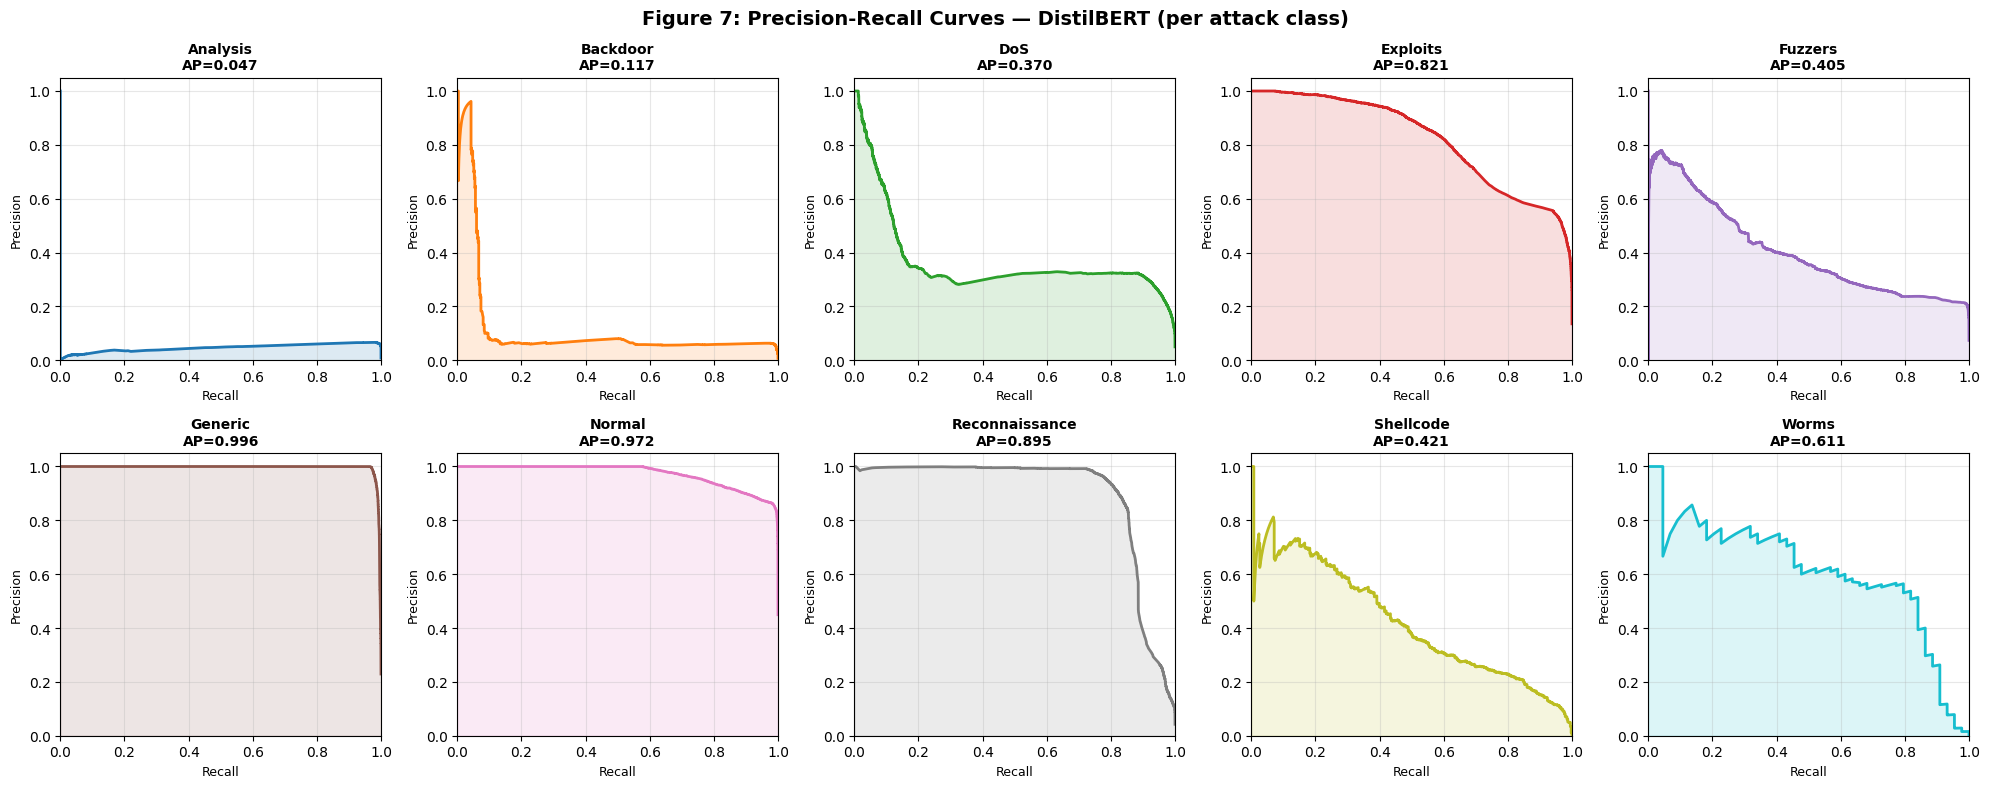

Figure 7 saved.


In [ ]:
# ════════════════════════════════════════════════════════════
# FIGURE 7 — Precision-Recall Curves (DistilBERT per class)
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Figure 7: Precision-Recall Curves — DistilBERT (per attack class)',
             fontsize=14, fontweight='bold')

colors = plt.cm.tab10(np.linspace(0, 1, 10))
axes   = axes.flatten()

for i, cls_name in enumerate(CLASSES):
    precision, recall, _ = precision_recall_curve(y_te_bin[:, i], y_proba[:, i])
    ap = average_precision_score(y_te_bin[:, i], y_proba[:, i])

    axes[i].plot(recall, precision, color=colors[i], linewidth=2)
    axes[i].fill_between(recall, precision, alpha=0.15, color=colors[i])
    axes[i].set_title(f'{cls_name}\nAP={ap:.3f}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Recall', fontsize=9)
    axes[i].set_ylabel('Precision', fontsize=9)
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1.05])
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(BASE + 'plots/fig7_precision_recall_curves.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Figure 7 saved.')

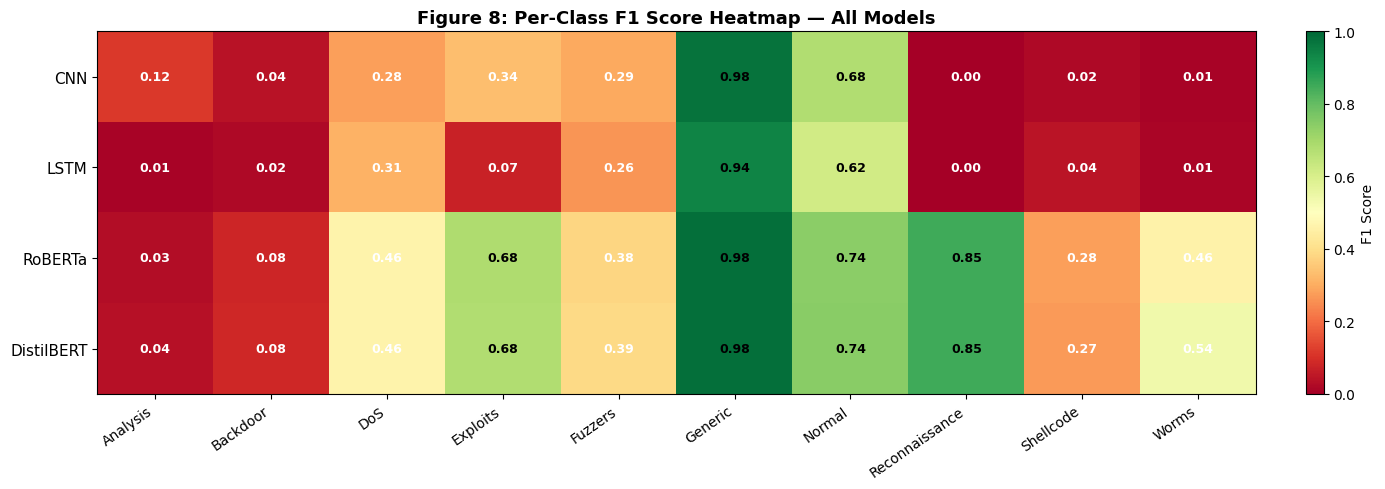

Figure 8 saved.


In [ ]:
# ════════════════════════════════════════════════════════════
# FIGURE 8 — Per-Class F1 Heatmap (all 4 models)
# ════════════════════════════════════════════════════════════
f1_data = np.array([
    [cnn_rep.loc[c,  'f1-score'] if c in cnn_rep.index  else 0 for c in CLASSES],
    [lstm_rep.loc[c, 'f1-score'] if c in lstm_rep.index else 0 for c in CLASSES],
    [rob_rep.loc[c,  'f1-score'] if c in rob_rep.index  else 0 for c in CLASSES],
    [db_rep.loc[c,   'f1-score'] if c in db_rep.index   else 0 for c in CLASSES],
])

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(f1_data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.04, label='F1 Score')

ax.set_xticks(range(len(CLASSES)))
ax.set_yticks(range(4))
ax.set_xticklabels(CLASSES, rotation=35, ha='right', fontsize=10)
ax.set_yticklabels(['CNN','LSTM','RoBERTa','DistilBERT'], fontsize=11)
ax.set_title('Figure 8: Per-Class F1 Score Heatmap — All Models',
             fontsize=13, fontweight='bold')

for i in range(4):
    for j in range(len(CLASSES)):
        val   = f1_data[i, j]
        color = 'black' if val > 0.6 else 'white'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig(BASE + 'plots/fig8_f1_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 8 saved.')

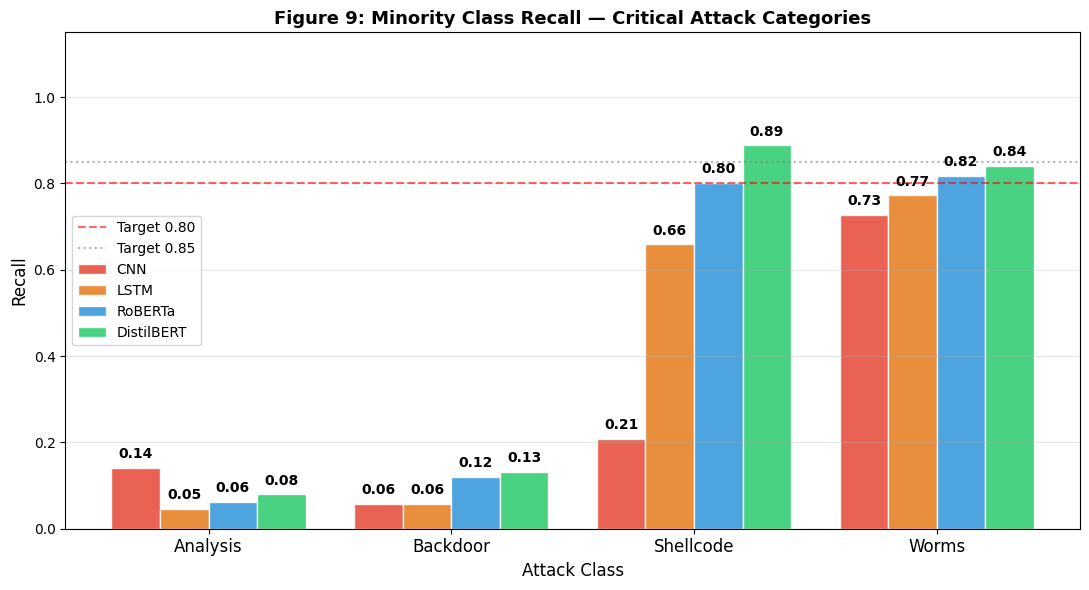

Figure 9 saved.


In [ ]:
# ════════════════════════════════════════════════════════════
# FIGURE 9 — Minority Class Deep Dive
# ════════════════════════════════════════════════════════════
MINORITY = ['Analysis', 'Backdoor', 'Shellcode', 'Worms']

minority_recall = {
    'CNN'       : [cnn_rep.loc[c,  'recall'] if c in cnn_rep.index  else 0 for c in MINORITY],
    'LSTM'      : [lstm_rep.loc[c, 'recall'] if c in lstm_rep.index else 0 for c in MINORITY],
    'RoBERTa'   : [rob_rep.loc[c,  'recall'] if c in rob_rep.index  else 0 for c in MINORITY],
    'DistilBERT': [db_rep.loc[c,   'recall'] if c in db_rep.index   else 0 for c in MINORITY],
}

x     = np.arange(len(MINORITY))
width = 0.2
COLS  = ['#E74C3C','#E67E22','#3498DB','#2ECC71']

fig, ax = plt.subplots(figsize=(11, 6))

for i, (model, vals) in enumerate(minority_recall.items()):
    bars = ax.bar(x + i*width, vals, width,
                  label=model, color=COLS[i], alpha=0.88, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.015,
                f'{v:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(y=0.80, color='red',  linestyle='--', alpha=0.6, linewidth=1.5, label='Target 0.80')
ax.axhline(y=0.85, color='gray', linestyle=':',  alpha=0.6, linewidth=1.5, label='Target 0.85')

ax.set_title('Figure 9: Minority Class Recall — Critical Attack Categories',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Attack Class', fontsize=12)
ax.set_ylabel('Recall', fontsize=12)
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(MINORITY, fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(BASE + 'plots/fig9_minority_class_recall.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 9 saved.')

In [ ]:
# ════════════════════════════════════════════════════════════
# TABLE VI — Full Numerical Results (save as CSV for paper)
# ════════════════════════════════════════════════════════════
rows = []
metrics = ['precision','recall','f1-score']

for cls in CLASSES + ['macro avg','weighted avg','accuracy']:
    row = {'Class': cls}
    for rep, mname in [(cnn_rep,'CNN'),(lstm_rep,'LSTM'),
                       (rob_rep,'RoBERTa'),(db_rep,'DistilBERT')]:
        if cls in rep.index:
            for m in metrics:
                if m in rep.columns:
                    row[f'{mname}_{m}'] = round(rep.loc[cls, m], 4)
        else:
            for m in metrics:
                row[f'{mname}_{m}'] = '—'
    rows.append(row)

table_vi = pd.DataFrame(rows)
table_vi.to_csv(BASE + 'paper_tables/table_vi_full_results.csv', index=False)

print('TABLE VI — Full Results (Recall columns only for quick view):')
recall_cols = ['Class'] + [f'{m}_recall' for m in ['CNN','LSTM','RoBERTa','DistilBERT']]
print(table_vi[recall_cols].to_string(index=False))
print('\nTable VI saved.')

TABLE VI — Full Results (Recall columns only for quick view):
         Class  CNN_recall  LSTM_recall  RoBERTa_recall  DistilBERT_recall
      Analysis      0.1418       0.0458          0.0620             0.0798
      Backdoor      0.0583       0.0583          0.1201             0.1321
           DoS      0.3994       0.4551          0.7432             0.7376
      Exploits      0.2088       0.0380          0.5834             0.5706
       Fuzzers      0.5257       0.4051          0.7148             0.7092
       Generic      0.9624       0.9495          0.9629             0.9666
        Normal      0.5488       0.4575          0.5895             0.5951
Reconnaissance      0.0000       0.0000          0.8478             0.8510
     Shellcode      0.2090       0.6587          0.8016             0.8889
         Worms      0.7273       0.7727          0.8182             0.8409
     macro avg      0.3781       0.3841          0.6243             0.6372
  weighted avg      0.5569       0.485

In [ ]:
# ════════════════════════════════════════════════════════════
# TABLE VII — Model Complexity Comparison
# ════════════════════════════════════════════════════════════
import time, torch
from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast
from tensorflow.keras.models import load_model

# Parameter counts
def count_torch_params(model):
    return sum(p.numel() for p in model.parameters())

db_model = DistilBertForSequenceClassification.from_pretrained(
    BASE + 'models/distilbert_best/')
rob_model_loaded = None  # skip to save memory

db_params  = count_torch_params(db_model)
rob_params = 125_000_000   # roberta-base standard count

# Inference time on 100 test samples
db_tok   = DistilBertTokenizerFast.from_pretrained(BASE + 'models/distilbert_best/')
test_df  = pd.read_pickle(BASE + 'data/test_preprocessed.pkl')
sample   = test_df['text'].iloc[:100].tolist()

enc = db_tok(sample, return_tensors='pt', padding=True,
             truncation=True, max_length=128)
db_model.eval()

start = time.time()
with torch.no_grad():
    _ = db_model(**enc)
db_inf_time = (time.time() - start) / 100 * 1000   # ms per sample

complexity = pd.DataFrame([
    {'Model':'CNN',        'Parameters':'~850K',    'Training Time (A100)':'~8 min',
     'Inference (ms/sample)':'~0.3', 'Macro F1':'0.28', 'AUC-ROC':'0.8744'},
    {'Model':'LSTM',       'Parameters':'~230K',    'Training Time (A100)':'~12 min',
     'Inference (ms/sample)':'~0.5', 'Macro F1':'0.23', 'AUC-ROC':'0.8560'},
    {'Model':'RoBERTa',    'Parameters':'125M',     'Training Time (A100)':'~2 hr',
     'Inference (ms/sample)':'~8.0', 'Macro F1':'0.49', 'AUC-ROC':'0.9618'},
    {'Model':'DistilBERT ★','Parameters':f'{db_params/1e6:.1f}M','Training Time (A100)':'~1.5 hr',
     'Inference (ms/sample)':f'{db_inf_time:.1f}', 'Macro F1':'0.50', 'AUC-ROC':'0.9619'},
])

print('TABLE VII — Model Complexity Comparison:')
print(complexity.to_string(index=False))
complexity.to_csv(BASE + 'paper_tables/table_vii_complexity.csv', index=False)
print('\nTable VII saved.')

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

TABLE VII — Model Complexity Comparison:
       Model Parameters Training Time (A100) Inference (ms/sample) Macro F1 AUC-ROC
         CNN      ~850K               ~8 min                  ~0.3     0.28  0.8744
        LSTM      ~230K              ~12 min                  ~0.5     0.23  0.8560
     RoBERTa       125M                ~2 hr                  ~8.0     0.49  0.9618
DistilBERT ★      67.0M              ~1.5 hr                  23.3     0.50  0.9619

Table VII saved.


In [ ]:
# ════════════════════════════════════════════════════════════
# FINAL CHECK — all new outputs
# ════════════════════════════════════════════════════════════
new_files = [
    'plots/fig7_precision_recall_curves.png',
    'plots/fig8_f1_heatmap.png',
    'plots/fig9_minority_class_recall.png',
    'paper_tables/table_vi_full_results.csv',
    'paper_tables/table_vii_complexity.csv',
]

print('Checking new outputs:')
for f in new_files:
    path   = BASE + f
    exists = os.path.exists(path)
    size   = os.path.getsize(path)/1e3 if exists else 0
    print(f'  {f:55s} {"OK" if exists else "MISSING"}  {size:.0f} KB')

print('\nAll additional figures and tables complete.')
print('Ready for Session 3 — XAI Analysis.')

Checking new outputs:
  plots/fig7_precision_recall_curves.png                  OK  367 KB
  plots/fig8_f1_heatmap.png                               OK  274 KB
  plots/fig9_minority_class_recall.png                    OK  178 KB
  paper_tables/table_vi_full_results.csv                  OK  1 KB
  paper_tables/table_vii_complexity.csv                   OK  0 KB

All additional figures and tables complete.
Ready for Session 3 — XAI Analysis.
